In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the original training data
train = pd.read_csv("../data/raw/train.csv")

train["Date"] = pd.to_datetime(train["Date"])

# Keep only open stores
open_sales = train[train["Open"] == 1]

# Aggregate sales across stores by date
daily_sales = (
    open_sales
    .groupby("Date")["Sales"]
    .sum()
    .reset_index()
    .sort_values("Date")
)

daily_sales.head()

/var/folders/vk/6pn68sk92z93wvsph2msbyvh0000gn/T/ipykernel_24290/3193343844.py:5: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("../data/raw/train.csv")


,Date,Sales
0,2013-01-01,97235
1,2013-01-02,6949829
2,2013-01-03,6347820
3,2013-01-04,6638954
4,2013-01-05,5951593


In [2]:
test_size = 30

train_data = daily_sales.iloc[:-test_size].copy()
test_data = daily_sales.iloc[-test_size:].copy()

print("Training:", train_data["Date"].min(), "to", train_data["Date"].max())
print("Testing :", test_data["Date"].min(), "to", test_data["Date"].max())

Training: 2013-01-01 00:00:00 to 2015-07-01 00:00:00
Testing : 2015-07-02 00:00:00 to 2015-07-31 00:00:00


In [3]:
train_ts = train_data.set_index("Date")["Sales"]

train_ts.head()

Date
2013-01-01      97235
2013-01-02    6949829
2013-01-03    6347820
2013-01-04    6638954
2013-01-05    5951593
Name: Sales, dtype: int64

In [4]:
print("Number of training observations:", len(train_ts))
print("Start:", train_ts.index.min())
print("End:", train_ts.index.max())

Number of training observations: 912
Start: 2013-01-01 00:00:00
End: 2015-07-01 00:00:00


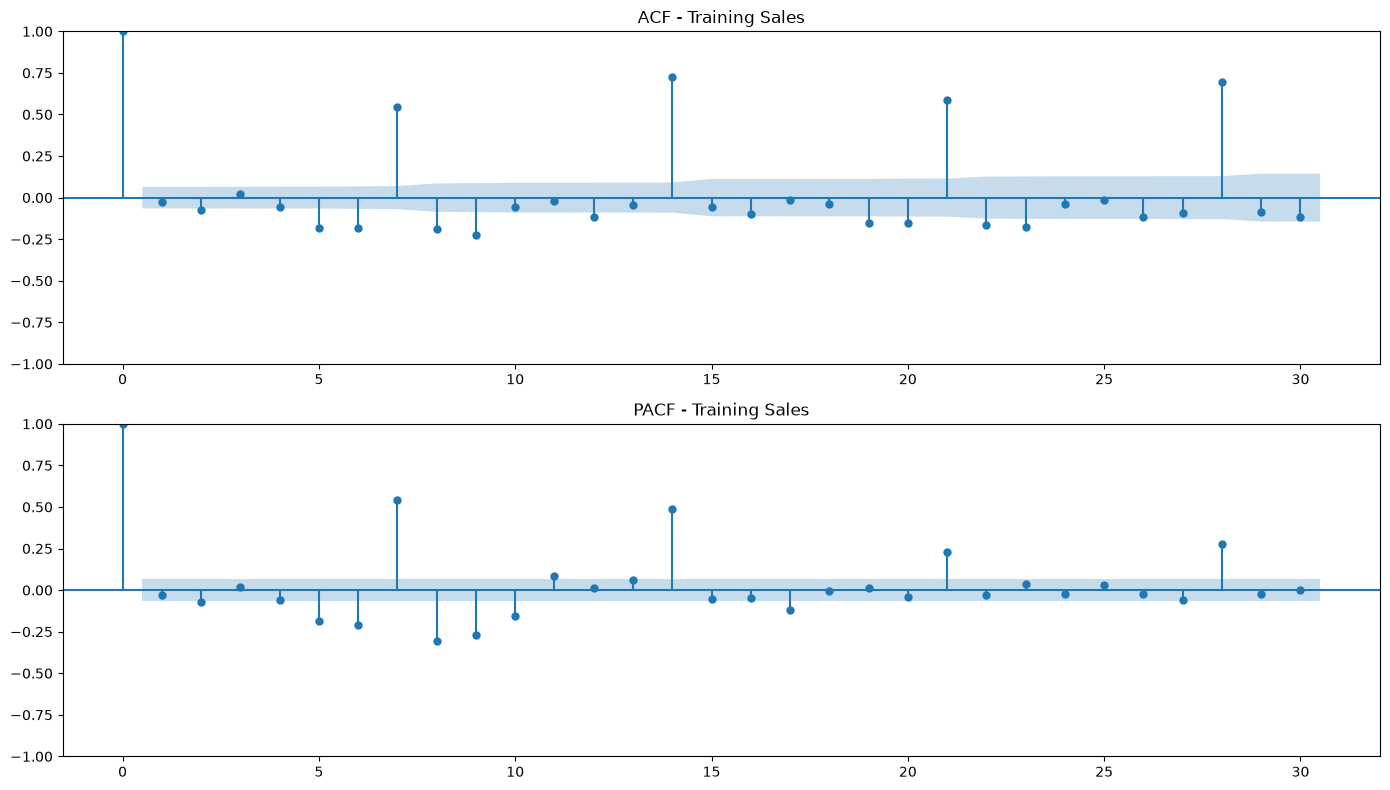

In [5]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(train_ts, lags=30, ax=ax[0])
ax[0].set_title("ACF - Training Sales")

plot_pacf(train_ts, lags=30, ax=ax[1])
ax[1].set_title("PACF - Training Sales")

plt.tight_layout()
plt.show()

In [6]:
from statsmodels.tsa.arima.model import ARIMA

# Create ARIMA model
arima_model = ARIMA(train_ts, order=(7, 0, 0))

# Fit the model
arima_result = arima_model.fit()

print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                  912
Model:                 ARIMA(7, 0, 0)   Log Likelihood              -14732.912
Date:                Fri, 21 Aug 2026   AIC                          29483.824
Time:                        16:53:34   BIC                          29527.165
Sample:                    01-01-2013   HQIC                         29500.370
                         - 07-01-2015                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.217e+06   1.21e+05     51.509      0.000    5.98e+06    6.45e+06
ar.L1          0.0369      0.019      1.899      0.058      -0.001       0.075
ar.L2          0.0212      0.027      0.787      0.4

/Users/mansisachinkhairnar/Projects/demand-forecasting-time-series/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mansisachinkhairnar/Projects/demand-forecasting-time-series/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mansisachinkhairnar/Projects/demand-forecasting-time-series/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [7]:
arima_forecast = arima_result.forecast(steps=len(test_data))

y_pred_arima = arima_forecast.values

print("Number of forecasts:", len(y_pred_arima))
print(y_pred_arima[:10])

Number of forecasts: 30
[7065285.27486619 7126611.67681383 6327240.62948934 1023473.65970406
 7825269.30805352 8393973.17377282 7328091.7431422  7102073.05424836
 7483161.47837015 6871596.66568249]


In [8]:
arima_results = test_data[["Date", "Sales"]].copy()

arima_results["ARIMA_Forecast"] = y_pred_arima

arima_results.head(10)

,Date,Sales,ARIMA_Forecast
912,2015-07-02,8446293,7.065285e+06
913,2015-07-03,8530388,7.126612e+06
914,2015-07-04,6054276,6.327241e+06
915,2015-07-05,269248,1.023474e+06
916,2015-07-06,7540473,7.825269e+06
917,2015-07-07,6393024,8.393973e+06
918,2015-07-08,6915625,7.328092e+06
919,2015-07-09,6938182,7.102073e+06
920,2015-07-10,7064909,7.483161e+06
921,2015-07-11,6262022,6.871597e+06


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test_data["Sales"], arima_forecast)
rmse = np.sqrt(mean_squared_error(test_data["Sales"], arima_forecast))

# Avoid division by zero for MAPE
actual = test_data["Sales"].values
predicted = np.array(arima_forecast)

mask = actual != 0
mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

print("ARIMA Forecast Performance")
print("--------------------------")
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"MAPE : {mape:.2f}%")

ARIMA Forecast Performance
--------------------------
MAE  : 1,691,287.62
RMSE : 2,217,356.91
MAPE : 155.47%


In [11]:
arima_results = test_data[["Date", "Sales"]].copy()

arima_results["ARIMA_Forecast"] = np.array(arima_forecast)

arima_results.head(10)

,Date,Sales,ARIMA_Forecast
912,2015-07-02,8446293,7.065285e+06
913,2015-07-03,8530388,7.126612e+06
914,2015-07-04,6054276,6.327241e+06
915,2015-07-05,269248,1.023474e+06
916,2015-07-06,7540473,7.825269e+06
917,2015-07-07,6393024,8.393973e+06
918,2015-07-08,6915625,7.328092e+06
919,2015-07-09,6938182,7.102073e+06
920,2015-07-10,7064909,7.483161e+06
921,2015-07-11,6262022,6.871597e+06


In [12]:
actual = test_data["Sales"].values
predicted = np.array(arima_forecast)

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))

mask = actual != 0
mape = np.mean(
    np.abs((actual[mask] - predicted[mask]) / actual[mask])
) * 100

print("ARIMA Forecast Performance")
print("--------------------------")
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"MAPE : {mape:.2f}%")

ARIMA Forecast Performance
--------------------------
MAE  : 1,691,287.62
RMSE : 2,217,356.91
MAPE : 155.47%


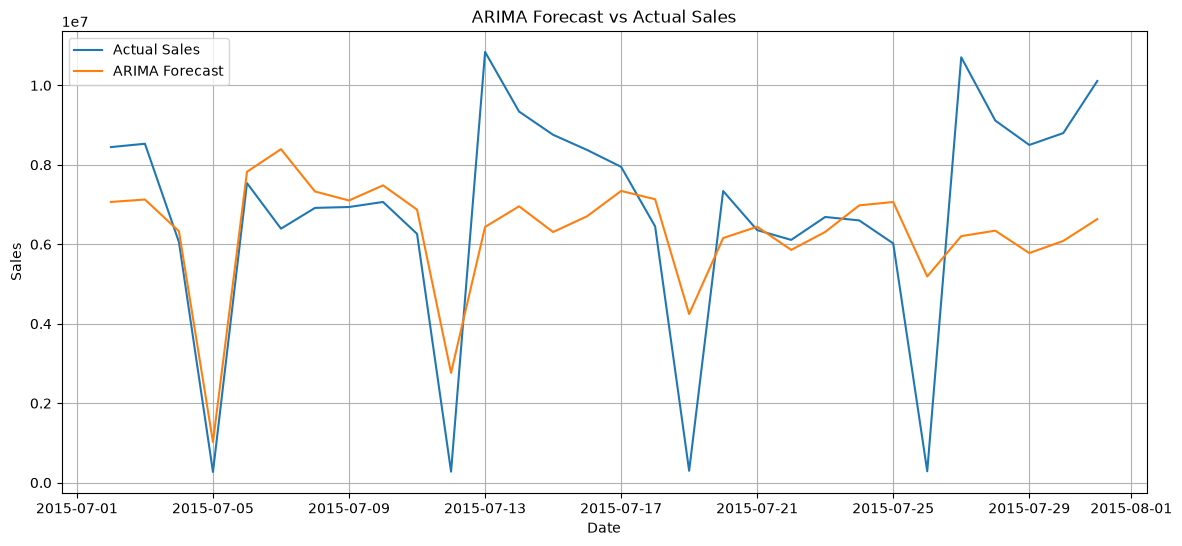

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    test_data["Date"],
    test_data["Sales"],
    label="Actual Sales"
)

plt.plot(
    test_data["Date"],
    arima_forecast,
    label="ARIMA Forecast"
)

plt.title("ARIMA Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

In [14]:
comparison = pd.DataFrame({
    "Model": [
        "Naive",
        "Seasonal Naive",
        "Random Forest",
        "ARIMA"
    ],
    "MAE": [
        2556268.47,
        1614210.23,
        788853.02,
        1691287.62
    ],
    "RMSE": [
        3626993.83,
        2260598.83,
        1550665.98,
        2217356.91
    ],
    "MAPE": [
        431.40,
        22.18,
        78.90,
        155.47
    ]
})

comparison

,Model,MAE,RMSE,MAPE
0,Naive,2556268.47,3626993.83,431.40
1,Seasonal Naive,1614210.23,2260598.83,22.18
2,Random Forest,788853.02,1550665.98,78.90
3,ARIMA,1691287.62,2217356.91,155.47


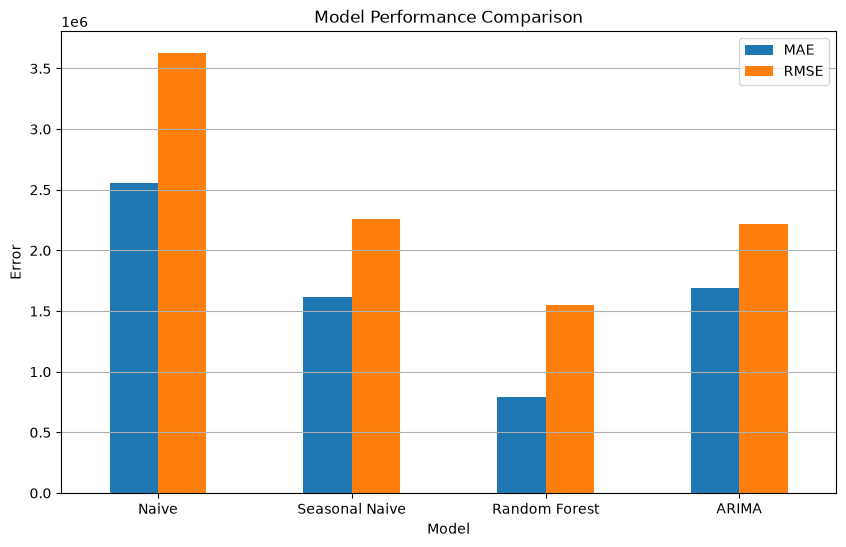

In [15]:
comparison.set_index("Model")[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()